# Telco Customer Churn Data Preprocessing

## Project Objective

This notebook demonstrates a complete data preprocessing workflow for the IBM Telco Customer Churn dataset using Machine Learning engineering best practices.

The preprocessing workflow includes:

- Data loading and exploration
- Data quality assessment
- Missing value analysis and treatment
- Duplicate detection
- Invalid value detection
- Data type correction
- Categorical data cleaning
- Feature engineering
- Categorical encoding
- Numerical scaling
- Train-test splitting
- Data leakage prevention
- Scikit-Learn preprocessing pipeline

### Dataset

IBM Telco Customer Churn

### Problem Type

Binary Classification

### Target Variable

`Churn`

### Goal

Prepare a clean, reusable dataset suitable for machine learning models while organizing preprocessing logic inside reusable modules located in the `src/` directory.

In [25]:
#Import Libraries

# -------------------------
# Standard Libraries
# -------------------------

import os
import sys
import warnings
import importlib

warnings.filterwarnings("ignore")



# -------------------------
# Add Project Root to Path
# -------------------------

PROJECT_ROOT = os.path.abspath("..")


if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


print(f"Project Root: {PROJECT_ROOT}")



# -------------------------
# Data Manipulation
# -------------------------

import numpy as np
import pandas as pd



# -------------------------
# Visualization
# -------------------------

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


plt.style.use("ggplot")

sns.set_theme(
    style="whitegrid"
)


pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

pd.set_option(
    "display.width",
    None
)



# -------------------------
# Machine Learning
# -------------------------

from sklearn.model_selection import (
    train_test_split
)



# ==========================================================
# Reload Source Modules
# ==========================================================

import src.utils
import src.preprocessing


importlib.reload(
    src.utils
)

importlib.reload(
    src.preprocessing
)



# Load pipeline only if it exists

try:

    import src.pipeline

    importlib.reload(
        src.pipeline
    )

    from src.pipeline import *

    print("Pipeline module loaded")

except ModuleNotFoundError:

    print(
        "Pipeline module not created yet"
    )



# ==========================================================
# Import Project Functions
# ==========================================================

from src.utils import *

from src.preprocessing import *


print(
    "✅ All libraries imported successfully."
)

Project Root: c:\Users\abuba\Downloads\ML-Projects\Day-3
Pipeline module loaded
✅ All libraries imported successfully.


## Load Dataset

In [2]:
train_df = pd.read_csv(
    "../datasets/telco_customer_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

print("Dataset Shape:", train_df.shape)

display(train_df.head())

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# initial exploration
print("Dataset Information")

train_df.info()

print("\nDataset Shape")

print(train_df.shape)

print("\nStatistical Summary")

display(train_df.describe(include="all"))

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null  

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [4]:
# Data Types
display(
    train_df.dtypes
)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [5]:
# Data Type Conversion

train_df = convert_telco_data_types(train_df)

display(
    check_data_types(train_df)
)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [6]:
# missing values
missing = missing_values_summary(train_df)

display(missing)

,Missing_Count,Missing_Percentage
TotalCharges,11,0.156183


<Figure size 1400x600 with 0 Axes>

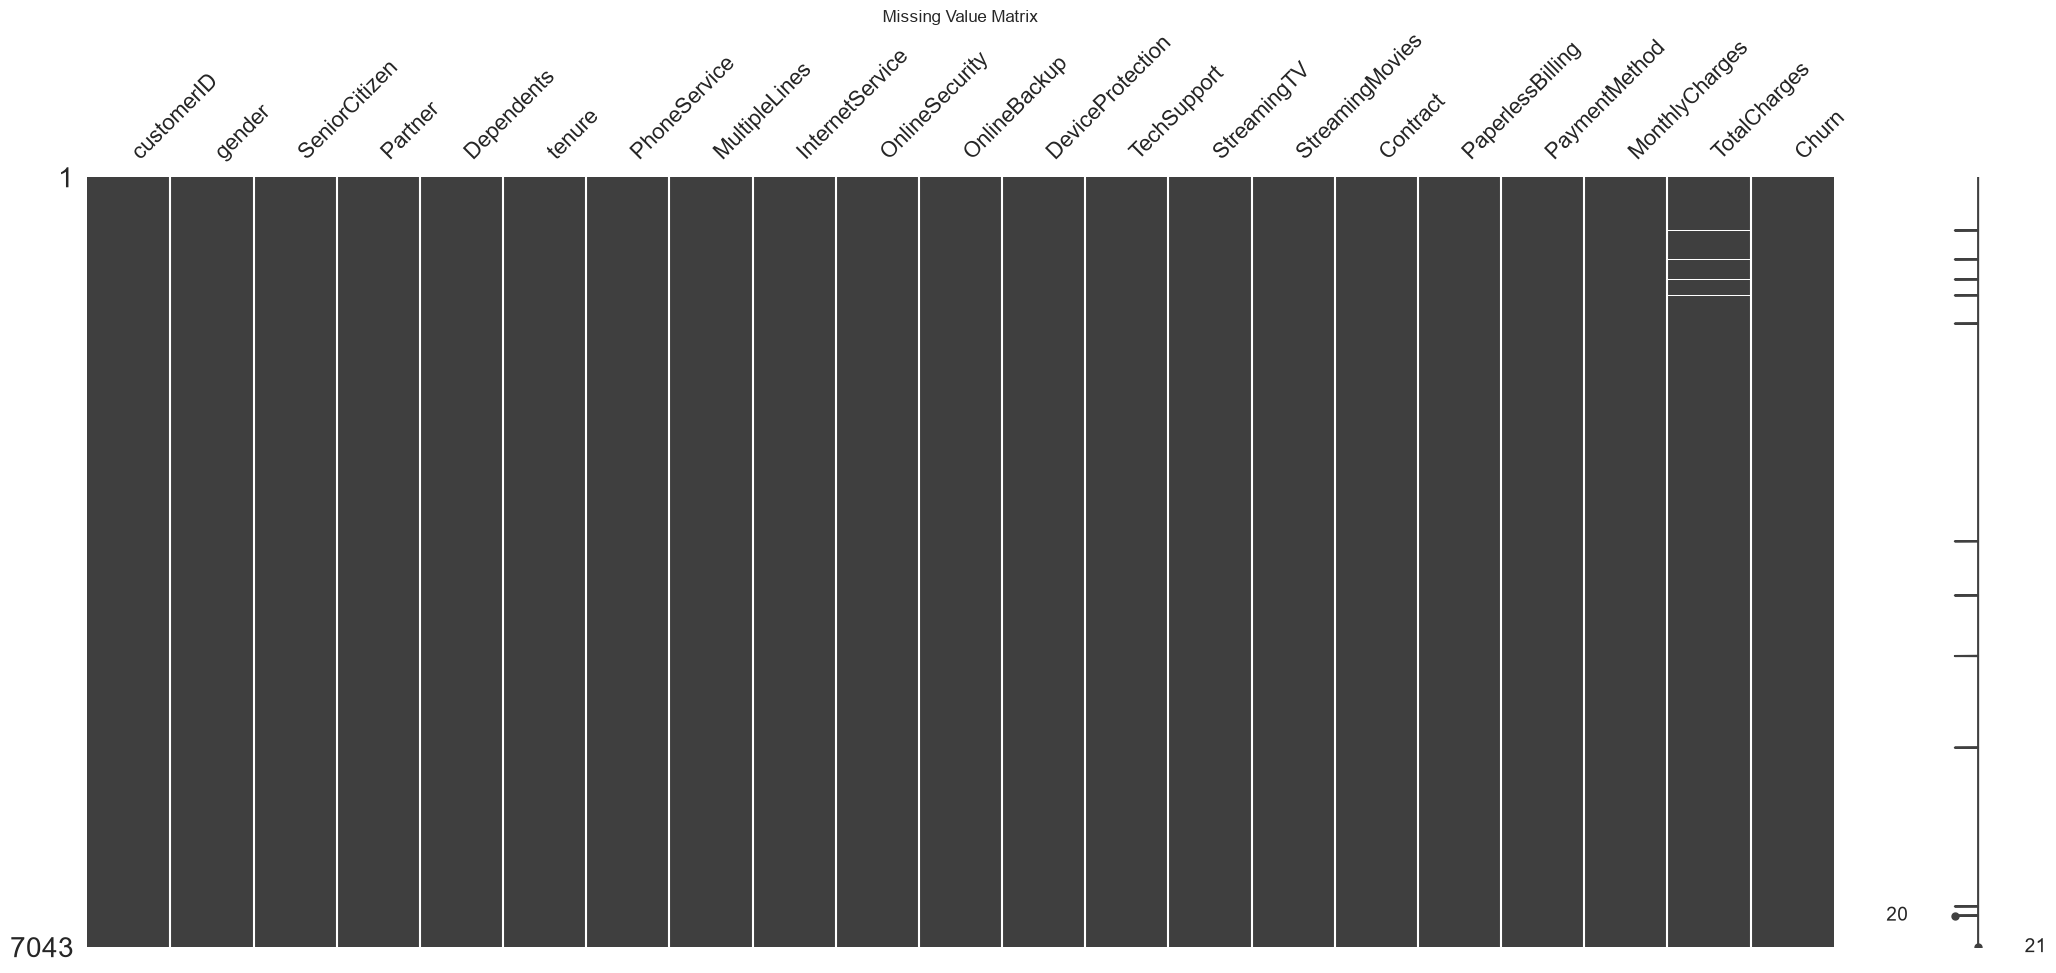

In [7]:
# missing values visualization
plt.figure(figsize=(14,6))

msno.matrix(train_df)

plt.title(
    "Missing Value Matrix"
)

plt.show()


In [8]:
missing_count = train_df.isnull().sum()

missing_percentage = (
    train_df.isnull().sum() / len(train_df)
) * 100

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

display(missing_summary)

,Missing_Count,Missing_Percentage
customerID,0,0.000000
gender,0,0.000000
SeniorCitizen,0,0.000000
Partner,0,0.000000
Dependents,0,0.000000
tenure,0,0.000000
PhoneService,0,0.000000
MultipleLines,0,0.000000
InternetService,0,0.000000
OnlineSecurity,0,0.000000


In [9]:
print(f"Total Missing Values: {train_df.isnull().sum().sum()}")

Total Missing Values: 11


# Missing Value Analysis

The missing value assessment indicates that the Telco Customer Churn dataset is complete and does not contain any missing values.

## Key Observations

- All **21 features** have **0 missing values**.
- The dataset contains **7,043 customer records** with complete information.
- No numerical or categorical feature requires imputation.
- Since no missing values are present, the dataset is ready for the next preprocessing steps.

## Conclusion

No missing value treatment is required. The preprocessing workflow can proceed with duplicate detection, data type verification, category cleaning, feature engineering, encoding, and scaling.

In [10]:
# Duplicate Records
duplicate_records = train_df.duplicated().sum()
print(f"Total Duplicate Records: {duplicate_records}")


Total Duplicate Records: 0


# Duplicate Record Analysis

Duplicate records can introduce bias into machine learning models by giving disproportionate importance to repeated observations.

The dataset was inspected for duplicate rows before any preprocessing.

## Observation

No duplicate records were found in the dataset, indicating that each customer record is unique.

## invalid Values

In [11]:
invalid = check_invalid_values(train_df)

print(invalid)

{}


# Invalid Value Assessment

The numerical features were examined for invalid values such as negative numbers in fields where only non-negative values are expected.

## Observation

No invalid numerical values were detected in the dataset.

## Category Cleaning

In [12]:
train_df = clean_categories(train_df)

In [13]:
train_df = clean_categories(train_df)

display(train_df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-vhveg,female,0,yes,no,1,no,no phone service,dsl,no,yes,no,no,no,no,month-to-month,yes,electronic check,29.85,29.85,no
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,no,yes,no,no,no,one year,no,mailed check,56.95,1889.50,no
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,yes,no,no,no,no,month-to-month,yes,mailed check,53.85,108.15,yes
3,7795-cfocw,male,0,no,no,45,no,no phone service,dsl,yes,no,yes,yes,no,no,one year,no,bank transfer (automatic),42.30,1840.75,no
4,9237-hqitu,female,0,no,no,2,yes,no,fiber optic,no,no,no,no,no,no,month-to-month,yes,electronic check,70.70,151.65,yes


## Feature Engeneering

In [14]:
print(train_df["TotalCharges"].dtype)

float64


In [15]:
train_df = create_telco_features(train_df)

display(
    train_df[
        [
            "tenure",
            "TenureGroup",
            "AverageMonthlySpend",
            "IsSenior",
            "HasDependents"
        ]
    ].head()
)

,tenure,TenureGroup,AverageMonthlySpend,IsSenior,HasDependents
0,1,0-12 Months,29.850000,0,1
1,34,25-48 Months,55.573529,0,0
2,2,0-12 Months,54.075000,0,0
3,45,25-48 Months,40.905556,0,0
4,2,0-12 Months,75.825000,0,0


## Drop the ID column

In [18]:
X = train_df.drop(
    columns=[
        "customerID",
        "Churn"
    ]
)

y = train_df["Churn"]

print(X.shape)
print(y.shape)

(7043, 23)
(7043,)


In [26]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(5634, 23)
(1409, 23)


In [27]:
#using the pipeline to preprocess the data
preprocessor = create_preprocessor(X_train)

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [28]:
# verification of the processed data
print(type(X_train_processed))
print(type(X_test_processed))

print(X_train_processed.shape)
print(X_test_processed.shape)

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
(5634, 37)
(1409, 37)


## Processed Data Summary

In [29]:

print("Original Training Shape :", X_train.shape)
print("Processed Training Shape:", X_train_processed.shape)

print()

print("Original Testing Shape :", X_test.shape)
print("Processed Testing Shape:", X_test_processed.shape)


Original Training Shape : (5634, 23)
Processed Training Shape: (5634, 37)

Original Testing Shape : (1409, 23)
Processed Testing Shape: (1409, 37)


# Processed Dataset Summary

The preprocessing pipeline successfully transformed the original dataset into a machine learning-ready format.

## Observations

- The number of observations remained unchanged after preprocessing.
- The number of features increased due to One-Hot Encoding of categorical variables.
- Numerical features were standardized using `StandardScaler`.
- The pipeline was fitted only on the training data to prevent data leakage.

The processed datasets are now suitable for machine learning model training and evaluation.